# Dynamic Hand Mapping — Video Keypoints to Inspire RH56

**Overview**

| Phase | Description |
|-------|-------------|
| 0 | Setup — install/import dependencies |
| 1 | Load a hand-pose video dataset clip |
| 2 | Extract MediaPipe Hands keypoints per frame |
| 3 | Compute joint angles from 3D world-space landmarks |
| 4 | Map joint angles → Inspire RH56 DOF positions via calibration anchors |
| 5 | Clamp values and enforce soft collision limits |
| 6 | Inspire Hand interface (Modbus RTU / mock) |
| 7 | Replay DOF sequence to hardware |
| 8 | Persist extracted keypoints and DOF sequence |

**DOF order** for all robot position arrays: `[little, ring, middle, index, thumb_bend, thumb_rotation]`

**Angle extraction** uses MediaPipe 3D world-space landmarks (origin at palm centre, units in metres) so the mapping is invariant to camera distance and hand position in the frame.


## Phase 0 — Setup

In [291]:
%pip install -q mediapipe numpy matplotlib opencv-python pymodbus pyserial tqdm


Note: you may need to restart the kernel to use updated packages.


In [292]:
import gc
import csv
import random
import time
from pathlib import Path
from typing import List, Optional, Tuple

import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import serial
from tqdm.auto import tqdm
from pymodbus.client import ModbusSerialClient

# DOF Constants
DOF_NAMES = ["Little", "Ring", "Middle", "Index", "Thumb Bend", "Thumb Rot"]
N_DOFS    = 6
POS_MIN, POS_MAX = 0, 1000

# RH56 series modbus USB-CH340 defaults 
DEFAULT_PORT  = "/dev/ttyUSB0"
DEFAULT_BAUD  = 115200
DEVICE_ID     = 1
REG_ANGLE_SET = 1486
REG_ANGLE_ACT = 1546
WRIST                                          = 0
THUMB_CMC, THUMB_MCP, THUMB_IP, THUMB_TIP     = 1, 2, 3, 4
INDEX_MCP, INDEX_PIP, INDEX_DIP, INDEX_TIP    = 5, 6, 7, 8
MIDDLE_MCP, MIDDLE_PIP, MIDDLE_DIP, MIDDLE_TIP = 9, 10, 11, 12
RING_MCP,  RING_PIP,  RING_DIP,  RING_TIP     = 13, 14, 15, 16
LITTLE_MCP, LITTLE_PIP, LITTLE_DIP, LITTLE_TIP = 17, 18, 19, 20

# Path defaults
VIDEOS_DIR    = Path("videos")
VIDEO_FILE    = VIDEOS_DIR / "hand_gestures.mp4"
KEYPOINTS_FILE = Path("keypoints.npy")
ANGLES_FILE   = Path("angles.npy")
DOF_SEQ_FILE  = Path("dof_sequence.npy")

# MediaPipe Tasks model file candidates
_TASK_MODEL_CANDIDATES = [
    Path("hand_landmarker.task"),
    Path("static_hand_mappings/hand_landmarker.task"),
    Path("../static_hand_mappings/hand_landmarker.task"),
]
HAND_LANDMARKER_TASK = next(
    (p for p in _TASK_MODEL_CANDIDATES if p.exists()),
    _TASK_MODEL_CANDIDATES[-1],
)

# Hand skeleton edges (same topology as MediaPipe Hands).
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (5, 9), (9, 10), (10, 11), (11, 12),
    (9, 13), (13, 14), (14, 15), (15, 16),
    (13, 17), (17, 18), (18, 19), (19, 20),
    (0, 17),
    (2, 5), (5, 9), (9, 13), (13, 17),
]

# Temporal filtering defaults (higher stability for hardware replay).
EMA_ALPHA = 0.15           # lower = smoother, higher = more responsive
MEDIAN_WINDOW = 3          # odd integer window for spike rejection
POSITION_DEADBAND = 3.0    # ignore tiny command changes to reduce chatter

print("Setup complete.")
print(f"HandLandmarker model path: {HAND_LANDMARKER_TASK}")

Setup complete.
HandLandmarker model path: ../static_hand_mappings/hand_landmarker.task


## Phase 1 — Load Video from a Hand-Pose Dataset


In [296]:
GESTURE = None  # one | four | small | fist | me | None
RANDOM_SEED = 40  # set to an int for reproducible sampling

# Common candidate locations depending on notebook working directory.
dataset_candidates = [
    Path("gr_dataset/gr"),
    Path("dynamic_hand_mappings/gr_dataset/gr"),
]

dataset_root = next((p for p in dataset_candidates if p.exists()), None)
if dataset_root is None:
    raise FileNotFoundError(
        "Could not find dataset folder. Expected one of: "
        + ", ".join(str(p) for p in dataset_candidates)
    )

csv_path = dataset_root / "Gesture Recognition.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"Missing metadata CSV: {csv_path}")


rng = random.Random(RANDOM_SEED) if RANDOM_SEED is not None else random
candidates = []

with csv_path.open("r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter=";")
    gesture_columns = [c for c in (reader.fieldnames or []) if c != "set_id"]

    if GESTURE is not None and GESTURE not in gesture_columns:
        raise ValueError(
            f"Gesture '{GESTURE}' not found. Available: {gesture_columns}"
        )

    use_gestures = [GESTURE] if GESTURE is not None else gesture_columns

    for row in reader:
        set_id = int(row["set_id"])
        for gesture_name in use_gestures:
            rel_path = row.get(gesture_name)
            if not rel_path:
                continue
            video_path = dataset_root / rel_path
            if video_path.exists():
                candidates.append((set_id, gesture_name, video_path))

if not candidates:
    raise FileNotFoundError(
        "No valid videos found from the dataset CSV and selected filter."
    )

SET_ID, selected_gesture, VIDEO_FILE = rng.choice(candidates)

cap = cv2.VideoCapture(str(VIDEO_FILE))
if not cap.isOpened():
    raise RuntimeError(f"Could not open selected video: {VIDEO_FILE}")

n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
duration = (n_frames / fps) if fps > 0 else float("nan")
cap.release()

print(f"Dataset root  : {dataset_root}")
print(f"Sample pool   : {len(candidates)} videos")
print(f"Selected clip : set_id={SET_ID}, gesture='{selected_gesture}'")
print(f"Using VIDEO_FILE -> {VIDEO_FILE}")
print(f"Frames={n_frames}, FPS={fps:.2f}, Duration={duration:.2f}s")

Dataset root  : gr_dataset/gr
Sample pool   : 6 videos
Selected clip : set_id=1, gesture='fist'
Using VIDEO_FILE -> gr_dataset/gr/files/1/fist.mp4
Frames=125, FPS=29.60, Duration=4.22s


## Phase 2 — Extract MediaPipe Hand Keypoints

Each video frame is processed by **MediaPipe Hands** to detect up to 21 3D world-space landmarks per hand.  
World-space coordinates (metres, palm-centred origin) are used because they are invariant to hand position and camera distance — making the downstream angle computation more robust than image-coordinate landmarks.

`keypoints[t]` shape: `(21, 3)` — or `None` if no hand was detected in frame `t`.


In [297]:
def extract_keypoints(
    video_path: Path,
    max_frames: Optional[int] = None,
    min_detection_confidence: float = 0.6,
    min_tracking_confidence: float = 0.5,
    model_asset_path: Optional[Path] = None,
) -> List[Optional[np.ndarray]]:
    model_path = Path(model_asset_path) if model_asset_path else HAND_LANDMARKER_TASK
    if not model_path.exists():
        raise FileNotFoundError(
            f"Hand Landmarker model not found: {model_path}. "
            "Provide model_asset_path or place hand_landmarker.task in the repo."
        )

    base_options = mp.tasks.BaseOptions(model_asset_path=str(model_path))
    options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=base_options,
        running_mode=mp.tasks.vision.RunningMode.VIDEO,
        num_hands=1,
        min_hand_detection_confidence=min_detection_confidence,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=min_tracking_confidence,
    )

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_local = cap.get(cv2.CAP_PROP_FPS) or 30.0
    limit = min(n_total, max_frames) if max_frames else n_total

    results_list: List[Optional[np.ndarray]] = []
    detected = 0

    with mp.tasks.vision.HandLandmarker.create_from_options(options) as landmarker:
        with tqdm(total=limit, desc="Extracting keypoints") as pbar:
            for frame_idx in range(limit):
                ok, frame = cap.read()
                if not ok:
                    break

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
                timestamp_ms = int((frame_idx / max(fps_local, 1e-6)) * 1000.0)

                result = landmarker.detect_for_video(mp_image, timestamp_ms)

                arr = None
                if result.hand_world_landmarks:
                    lm = result.hand_world_landmarks[0]
                    arr = np.array([[p.x, p.y, p.z] for p in lm], dtype=np.float32)
                elif result.hand_landmarks:
                    # Fallback if world landmarks are unavailable for a frame.
                    lm = result.hand_landmarks[0]
                    arr = np.array([[p.x, p.y, p.z] for p in lm], dtype=np.float32)

                if arr is not None:
                    results_list.append(arr)
                    detected += 1
                else:
                    results_list.append(None)

                pbar.update(1)

    cap.release()

    pct = 100 * detected / max(len(results_list), 1)
    print(
        f"Frames processed: {len(results_list)}  |  "
        f"Hand detected: {detected} ({pct:.1f} %)"
    )
    return results_list


# Cap at 900 frames
keypoints_raw = extract_keypoints(VIDEO_FILE, max_frames=900)

# Persist raw keypoints
kp_arr = np.empty(len(keypoints_raw), dtype=object)
for i, kp in enumerate(keypoints_raw):
    kp_arr[i] = kp
np.save(KEYPOINTS_FILE, kp_arr, allow_pickle=True)
print(f"Keypoints saved  ->  {KEYPOINTS_FILE}")


I0000 00:00:1777326890.016787   56484 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777326890.053625   56501 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1777326890.275987   56487 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777326890.358883   56500 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Extracting keypoints: 100%|██████████| 125/125 [00:01<00:00, 69.65it/s]

Frames processed: 125  |  Hand detected: 69 (55.2 %)
Keypoints saved  ->  keypoints.npy


In [298]:
def visualise_keypoints(
    video_path: Path = VIDEO_FILE,
    model_asset_path: Optional[Path] = None,
    output_path: Path = Path("annotated_hand_overlay.mp4"),
) -> None:
    import shutil
    import subprocess

    model_path = Path(model_asset_path) if model_asset_path else HAND_LANDMARKER_TASK
    if not model_path.exists():
        raise FileNotFoundError(f"Hand Landmarker model not found: {model_path}")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video for visualisation: {video_path}")

    fps_local = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    raw_output_path = output_path.with_name(f"{output_path.stem}_raw.mp4")

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(raw_output_path), fourcc, fps_local, (width, height))
    if not writer.isOpened():
        cap.release()
        raise RuntimeError(f"Could not create output video: {raw_output_path}")

    base_options = mp.tasks.BaseOptions(model_asset_path=str(model_path))
    options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=base_options,
        running_mode=mp.tasks.vision.RunningMode.VIDEO,
        num_hands=1,
        min_hand_detection_confidence=0.6,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )

    with mp.tasks.vision.HandLandmarker.create_from_options(options) as landmarker:
        with tqdm(total=total, desc="Annotating video") as pbar:
            frame_idx = 0
            while True:
                ok, frame = cap.read()
                if not ok:
                    break

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
                timestamp_ms = int((frame_idx / max(fps_local, 1e-6)) * 1000.0)
                result = landmarker.detect_for_video(mp_image, timestamp_ms)

                annotated = frame.copy()
                if result.hand_landmarks:
                    hand_lm = result.hand_landmarks[0]

                    for start_idx, end_idx in HAND_CONNECTIONS:
                        p1 = hand_lm[start_idx]
                        p2 = hand_lm[end_idx]
                        x1, y1 = int(p1.x * width), int(p1.y * height)
                        x2, y2 = int(p2.x * width), int(p2.y * height)
                        cv2.line(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

                    for p in hand_lm:
                        x, y = int(p.x * width), int(p.y * height)
                        cv2.circle(annotated, (x, y), 3, (0, 0, 255), -1)

                writer.write(annotated)
                frame_idx += 1
                pbar.update(1)

    cap.release()
    writer.release()

    playable_path = raw_output_path
    ffmpeg_bin = shutil.which("ffmpeg")

    if ffmpeg_bin:
        cmd = [
            ffmpeg_bin,
            "-y",
            "-i", str(raw_output_path),
            "-c:v", "libx264",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",
            str(output_path),
        ]
        try:
            subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            playable_path = output_path
            print(f"H.264 video saved -> {output_path}")
        except subprocess.CalledProcessError as exc:
            print("ffmpeg conversion failed; using raw mp4v output.")
            err_tail = exc.stderr.decode("utf-8", errors="ignore")[-240:]
            if err_tail.strip():
                print(err_tail)
    else:
        print(
            "ffmpeg not found; using raw mp4v output. "
            "Install ffmpeg for better notebook playback compatibility."
        )

    print(f"Annotated video saved -> {raw_output_path}")
    from IPython.display import Video, display
    display(Video(str(playable_path), embed=True, width=min(960, width)))


visualise_keypoints(video_path=VIDEO_FILE)


I0000 00:00:1777326893.163669   56539 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777326893.189531   56556 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1777326893.311070   56543 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777326893.339433   56554 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Annotating video: 100%|██████████| 125/125 [00:02<00:00, 51.55it/s]


H.264 video saved -> annotated_hand_overlay.mp4
Annotated video saved -> annotated_hand_overlay_raw.mp4


## Phase 3 — Compute Joint Angles

We compute one **primary angle** per RH56 DOF from three consecutive landmark points:

| DOF | Joint measured | Landmark triple |
|-----|----------------|-----------------|
| Little | LITTLE PIP flexion | LITTLE_MCP → LITTLE_PIP → LITTLE_DIP |
| Ring | RING PIP flexion | RING_MCP → RING_PIP → RING_DIP |
| Middle | MIDDLE PIP flexion | MIDDLE_MCP → MIDDLE_PIP → MIDDLE_DIP |
| Index | INDEX PIP flexion | INDEX_MCP → INDEX_PIP → INDEX_DIP |
| Thumb bend | THUMB MCP flexion | THUMB_CMC → THUMB_MCP → THUMB_IP |
| Thumb rot | Thumb abduction | out-of-palm-plane elevation |

All angles are in **degrees**.  A straight finger measures ~170 °; a fully curled finger ~60–70 °.

In [299]:
def angle_3pt(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> float:
    ba    = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    bc    = np.asarray(c, dtype=float) - np.asarray(b, dtype=float)
    denom = np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-9
    cos_a = np.dot(ba, bc) / denom
    return float(np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0))))


def thumb_abduction_angle(kp: np.ndarray) -> float:
    wrist      = kp[WRIST]
    index_mcp  = kp[INDEX_MCP]
    little_mcp = kp[LITTLE_MCP]
    thumb_tip  = kp[THUMB_TIP]

    palm_v1 = index_mcp  - wrist
    palm_v2 = little_mcp - wrist
    normal  = np.cross(palm_v1, palm_v2)
    n_len   = np.linalg.norm(normal)
    if n_len < 1e-9:
        return 30.0            # fallback: midpoint of expected range
    normal /= n_len

    thumb_dir = thumb_tip - wrist
    t_len     = np.linalg.norm(thumb_dir)
    if t_len < 1e-9:
        return 30.0
    thumb_dir /= t_len

    sin_a = np.dot(thumb_dir, normal)
    return float(np.degrees(np.arcsin(np.clip(sin_a, -1.0, 1.0))))



def keypoints_to_angles(kp: np.ndarray) -> np.ndarray:
    return np.array([
        angle_3pt(kp[LITTLE_MCP], kp[LITTLE_PIP], kp[LITTLE_DIP]),  # 0 little
        angle_3pt(kp[RING_MCP],   kp[RING_PIP],   kp[RING_DIP]),    # 1 ring
        angle_3pt(kp[MIDDLE_MCP], kp[MIDDLE_PIP], kp[MIDDLE_DIP]),  # 2 middle
        angle_3pt(kp[INDEX_MCP],  kp[INDEX_PIP],  kp[INDEX_DIP]),   # 3 index
        angle_3pt(kp[THUMB_CMC],  kp[THUMB_MCP],  kp[THUMB_IP]),    # 4 thumb bend (MCP)
        thumb_abduction_angle(kp),                                    # 5 thumb rot
    ], dtype=np.float32)

In [300]:
# Sanity-check on the first detected frame
sample_kp = next(kp for kp in keypoints_raw if kp is not None)
sample_angles = keypoints_to_angles(sample_kp)
print("Sample joint angles:")
for name, angle in zip(DOF_NAMES, sample_angles):
    print(f"  {name:<16} {angle:6.1f} deg")
    

Sample joint angles:
  Little            103.2 deg
  Ring               89.3 deg
  Middle             90.0 deg
  Index             100.3 deg
  Thumb Bend        150.7 deg
  Thumb Rot         -10.8 deg


In [301]:
all_angles: List[Optional[np.ndarray]] = [
    keypoints_to_angles(kp) if kp is not None else None
    for kp in keypoints_raw
]

detected_angles = [a for a in all_angles if a is not None]
print(f"Angle arrays computed: {len(detected_angles)} frames with detected hand")

# Persist angles
ang_arr = np.empty(len(all_angles), dtype=object)
for i, a in enumerate(all_angles):
    ang_arr[i] = a
np.save(ANGLES_FILE, ang_arr, allow_pickle=True)
print(f"Angles saved  ->  {ANGLES_FILE}")

Angle arrays computed: 69 frames with detected hand
Angles saved  ->  angles.npy


## Phase 4 — Map Angles to RH56 DOF Positions

A **two-anchor linear calibration** maps each joint angle to a DOF register value:

$$
t_i = \frac{\theta_i - \theta^{\text{closed}}_i}{\theta^{\text{open}}_i - \theta^{\text{closed}}_i}
$$

$$
\text{pos}_i = \text{pos}^{\text{closed}}_i + \text{clip}(t_i, 0, 1)\; \cdot\; (\text{pos}^{\text{open}}_i - \text{pos}^{\text{closed}}_i)
$$

The reference angles below are representative MediaPipe world-space PIP measurements for a typical adult hand.  For best accuracy, re-calibrate by showing the robot hand in **fully open** and **fist** poses while recording the resulting MediaPipe angles.


In [302]:
# Calibration anchors (global priors).
OPEN_REF = np.array(
    [168.0, 168.0, 168.0, 168.0,   # little / ring / middle / index PIP
     165.0,                        # thumb IP (nearly straight)
      30.0],                       # thumb abduction (high = open)
    dtype=np.float32,
)

CLOSED_REF = np.array(
    [72.0, 72.0, 72.0, 72.0,       # little / ring / middle / index PIP (bent)
     50.0,                         # thumb IP (bent inward)
    -10.0],                        # thumb abduction (adducted)
    dtype=np.float32,
)

# Target DOF values at each anchor pose (RH56).
OPEN_POS   = np.full(N_DOFS, float(POS_MAX), dtype=np.float32)
CLOSED_POS = np.array([0, 0, 0, 0, 148, 894], dtype=np.float32)


def estimate_reference_anchors(
    angle_seq: List[Optional[np.ndarray]],
    prior_open: np.ndarray = OPEN_REF,
    prior_closed: np.ndarray = CLOSED_REF,
    q_open: float = 95.0,
    q_closed: float = 5.0,
    prior_blend: float = 0.35,
    min_span: np.ndarray = np.array([25, 25, 25, 25, 20, 15], dtype=np.float32),
) -> Tuple[np.ndarray, np.ndarray]:
    detected = [a for a in angle_seq if a is not None]
    if len(detected) < 10:
        return prior_open.copy(), prior_closed.copy()

    stacked = np.stack(detected).astype(np.float32)
    clip_open = np.percentile(stacked, q_open, axis=0).astype(np.float32)
    clip_closed = np.percentile(stacked, q_closed, axis=0).astype(np.float32)

    # Keep a healthy angular spread to avoid under-actuation on low-motion clips.
    clip_open = np.maximum(clip_open, clip_closed + min_span)

    # Blend clip-specific stats with priors for stability.
    open_ref = prior_blend * prior_open + (1.0 - prior_blend) * clip_open
    closed_ref = prior_blend * prior_closed + (1.0 - prior_blend) * clip_closed
    open_ref = np.maximum(open_ref, closed_ref + 5.0)

    return open_ref.astype(np.float32), closed_ref.astype(np.float32)


ACTIVE_OPEN_REF, ACTIVE_CLOSED_REF = estimate_reference_anchors(all_angles)

print("Active open ref  :", np.round(ACTIVE_OPEN_REF, 1).tolist())
print("Active closed ref:", np.round(ACTIVE_CLOSED_REF, 1).tolist())


def angles_to_dof(angles: np.ndarray) -> np.ndarray:
    span = ACTIVE_OPEN_REF - ACTIVE_CLOSED_REF
    t = (angles - ACTIVE_CLOSED_REF) / (span + 1e-9)
    t = np.clip(t, 0.0, 1.0)
    return (CLOSED_POS + t * (OPEN_POS - CLOSED_POS)).astype(np.float32)


# Verify anchor mappings
print("Open anchor   ->", angles_to_dof(ACTIVE_OPEN_REF).astype(int).tolist())
print("Closed anchor ->", angles_to_dof(ACTIVE_CLOSED_REF).astype(int).tolist())
print("Expected open  :", OPEN_POS.astype(int).tolist())
print("Expected closed:", CLOSED_POS.astype(int).tolist())

Active open ref  : [144.5, 140.39999389648438, 126.80000305175781, 141.1999969482422, 161.8000030517578, 5.199999809265137]
Active closed ref: [94.69999694824219, 80.0, 72.5999984741211, 84.0, 108.5999984741211, -18.5]
Open anchor   -> [1000, 1000, 1000, 1000, 1000, 1000]
Closed anchor -> [0, 0, 0, 0, 148, 894]
Expected open  : [1000, 1000, 1000, 1000, 1000, 1000]
Expected closed: [0, 0, 0, 0, 148, 894]


In [303]:
raw_dof: List[Optional[np.ndarray]] = [
    angles_to_dof(a) if a is not None else None
    for a in all_angles
]

detected_dof = [d for d in raw_dof if d is not None]
print(f"Raw DOF arrays: {len(detected_dof)} frames")

Raw DOF arrays: 69 frames


## Phase 5 — Clamp & Collision Prevention

Four layers of safety are applied before values reach the hardware:

1. **Hard clamp** — every DOF is restricted to `[POS_MIN, POS_MAX]` = `[0, 1000]`. This prevents register overflow on the RH56 Modbus interface.

2. **Soft collision rules** — the RH56 thumb geometry means a deeply closing thumb can collide with a closing index finger:
   - If `thumb_bend > 700`, cap `index` to ≤ 600.  
   - If `thumb_rotation < 200` (full adduction), cap `thumb_bend` to ≤ 400.  
   Tune these thresholds after mechanical characterisation of your unit.

3. **Temporal filtering** — hold-last-valid on missed detections, then a short median filter removes spikes, followed by exponential moving average (`α = 0.15`) for smooth trajectories.

4. **Command deadband** — tiny per-frame changes are suppressed so motors do not chatter around nearly constant positions.

In [304]:
def apply_hard_clamp(pos: np.ndarray) -> np.ndarray:
    return np.clip(pos, POS_MIN, POS_MAX).astype(np.float32)


def apply_collision_rules(pos: np.ndarray) -> np.ndarray:
    out        = pos.copy()
    thumb_bend = float(out[4])
    thumb_rot  = float(out[5])

    # thumb_bend uses RH56 scale: lower = more closed, higher = more open.
    if thumb_bend < 320.0:
        out[3] = min(out[3], 600.0)   # cap index only when thumb is strongly closed
    if thumb_rot < 900.0:
        out[4] = min(out[4], 450.0)   # cap thumb bend in deep adduction

    return out


def hold_last_valid(
    dof_seq: List[Optional[np.ndarray]],
) -> List[Optional[np.ndarray]]:
    out: List[Optional[np.ndarray]] = []
    last: Optional[np.ndarray] = None

    for pos in dof_seq:
        if pos is None:
            out.append(last.copy() if last is not None else None)
            continue
        last = pos.copy()
        out.append(last.copy())

    return out


def temporal_median_filter(
    dof_seq: List[Optional[np.ndarray]],
    window: int = MEDIAN_WINDOW,
    min_support: int = 3,
    ) -> List[Optional[np.ndarray]]:
    if window < 1 or window % 2 == 0:
        raise ValueError("window must be a positive odd integer")

    radius = window // 2
    out: List[Optional[np.ndarray]] = []
    n = len(dof_seq)

    for i in range(n):
        if dof_seq[i] is None:
            out.append(None)
            continue

        neighborhood = []
        for j in range(max(0, i - radius), min(n, i + radius + 1)):
            if dof_seq[j] is not None:
                neighborhood.append(dof_seq[j])

        if len(neighborhood) >= min_support:
            out.append(np.median(np.stack(neighborhood), axis=0).astype(np.float32))
        else:
            out.append(dof_seq[i].copy())

    return out


def smooth_dof_sequence(
    dof_seq: List[Optional[np.ndarray]],
    alpha: float = EMA_ALPHA,
    ) -> List[Optional[np.ndarray]]:
    smoothed: List[Optional[np.ndarray]] = []
    state: Optional[np.ndarray] = None

    for pos in dof_seq:
        if pos is None:
            smoothed.append(None)
            continue
        if state is None:
            state = pos.copy()
        else:
            state = alpha * pos + (1.0 - alpha) * state
        smoothed.append(state.copy())

    return smoothed


def apply_deadband(
    dof_seq: List[Optional[np.ndarray]],
    threshold: float = POSITION_DEADBAND,
    ) -> List[Optional[np.ndarray]]:
    out: List[Optional[np.ndarray]] = []
    last: Optional[np.ndarray] = None

    for pos in dof_seq:
        if pos is None:
            out.append(None)
            continue

        if last is None:
            filtered = pos.copy()
        else:
            filtered = np.where(np.abs(pos - last) < threshold, last, pos).astype(np.float32)

        out.append(filtered.copy())
        last = filtered.copy()

    return out


def process_dof_sequence(
    dof_seq: List[Optional[np.ndarray]],
) -> List[Optional[np.ndarray]]:
    stage0 = []
    for pos in dof_seq:
        if pos is None:
            stage0.append(None)
        else:
            p = apply_hard_clamp(pos)
            p = apply_collision_rules(p)
            stage0.append(p)

    stage1 = hold_last_valid(stage0)
    stage2 = temporal_median_filter(stage1, window=MEDIAN_WINDOW)
    stage3 = smooth_dof_sequence(stage2, alpha=EMA_ALPHA)
    stage4 = apply_deadband(stage3, threshold=POSITION_DEADBAND)

    return [
        apply_hard_clamp(p) if p is not None else None
        for p in stage4
    ]


safe_dof = process_dof_sequence(raw_dof)
detected_safe = [d for d in safe_dof if d is not None]
print(f"Safe DOF arrays: {len(detected_safe)} frames")

if detected_safe:
    stacked_safe = np.stack(detected_safe)
    assert stacked_safe.min() >= POS_MIN, "Clamp underflow detected!"
    assert stacked_safe.max() <= POS_MAX, "Clamp overflow detected!"
    print(
        f"Range check passed:  "
        f"min={stacked_safe.min():.0f}  max={stacked_safe.max():.0f}"
    )

Safe DOF arrays: 103 frames
Range check passed:  min=21  max=981


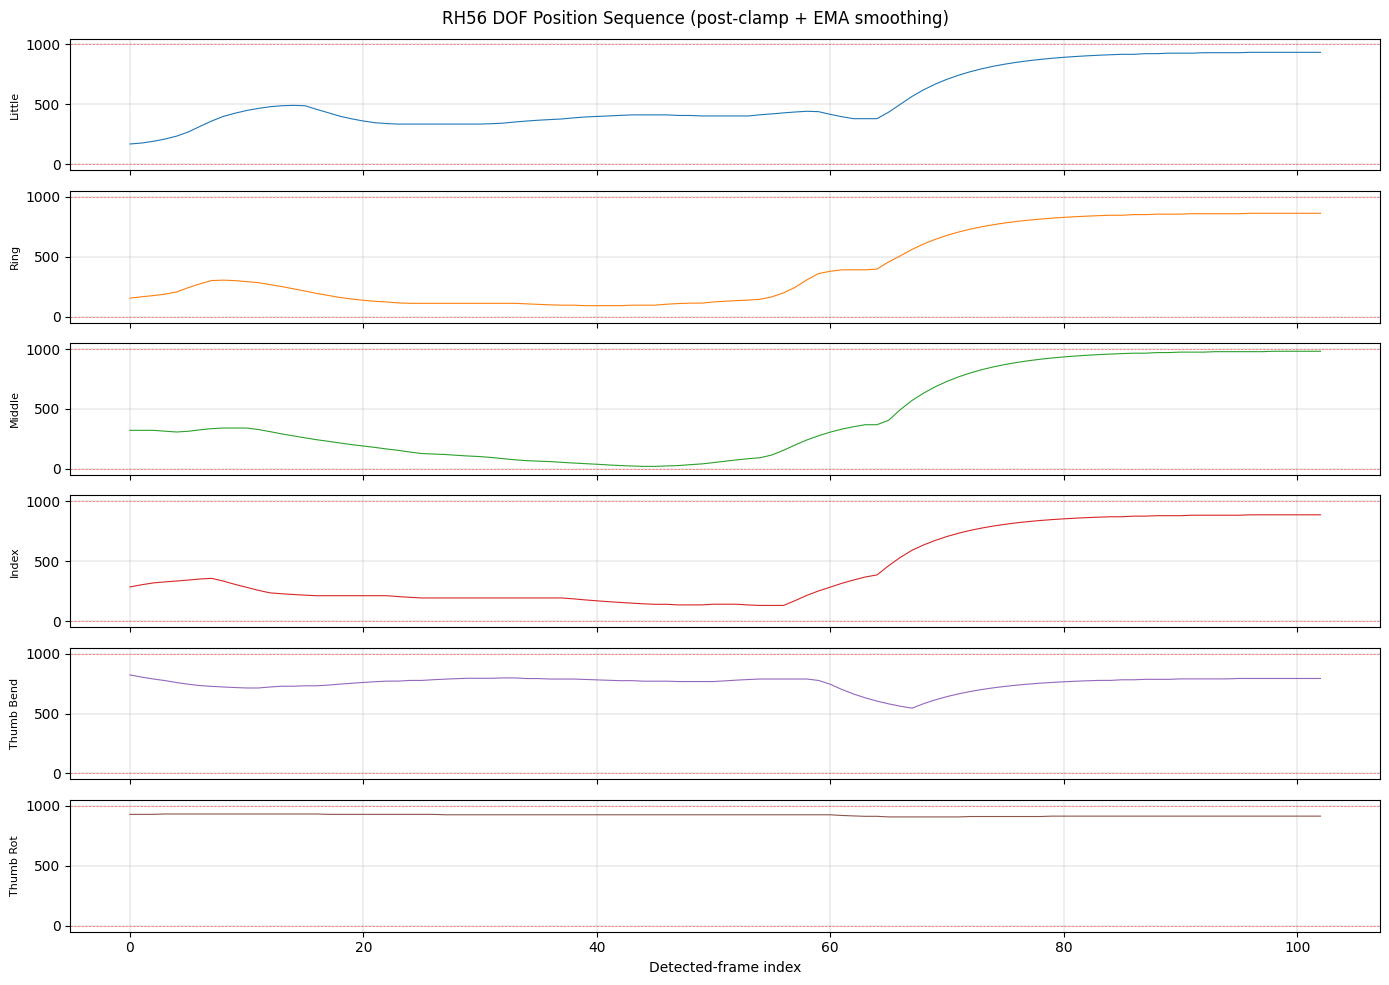


DOF                 min    max    mean     std
Little              170    935   551.5   245.7
Ring                 92    862   404.7   310.8
Middle               21    981   437.1   364.4
Index               132    887   439.6   300.4
Thumb Bend          544    822   752.4    55.4
Thumb Rot           907    932   921.4     7.9

DOF sequence saved  ->  dof_sequence.npy


In [305]:
if detected_safe:
    stacked_safe = np.stack(detected_safe)
    frames       = np.arange(len(stacked_safe))

    fig, axes = plt.subplots(N_DOFS, 1, figsize=(14, 10), sharex=True)
    colors    = plt.cm.tab10.colors

    for dof_idx, (ax, name) in enumerate(zip(axes, DOF_NAMES)):
        ax.plot(frames, stacked_safe[:, dof_idx], color=colors[dof_idx], lw=0.8)
        ax.set_ylabel(name, fontsize=8)
        ax.set_ylim(POS_MIN - 50, POS_MAX + 50)
        ax.axhline(POS_MIN, color="red", lw=0.5, linestyle="--", alpha=0.6)
        ax.axhline(POS_MAX, color="red", lw=0.5, linestyle="--", alpha=0.6)
        ax.grid(True, lw=0.3)

    axes[-1].set_xlabel("Detected-frame index")
    plt.suptitle("RH56 DOF Position Sequence (post-clamp + EMA smoothing)")
    plt.tight_layout()
    plt.show()

    print(f"\n{'DOF':<16} {'min':>6} {'max':>6} {'mean':>7} {'std':>7}")
    for idx, name in enumerate(DOF_NAMES):
        col = stacked_safe[:, idx]
        print(
            f"{name:<16} {col.min():>6.0f} {col.max():>6.0f} "
            f"{col.mean():>7.1f} {col.std():>7.1f}"
        )

# Persist safe DOF sequence
dof_arr = np.empty(len(safe_dof), dtype=object)
for i, d in enumerate(safe_dof):
    dof_arr[i] = d
np.save(DOF_SEQ_FILE, dof_arr, allow_pickle=True)
print(f"\nDOF sequence saved  ->  {DOF_SEQ_FILE}")


## Phase 6 — Inspire Hand Interface

Thin wrapper around the RH56 Modbus RTU protocol (pymodbus 3.13+).  
If the serial port is unavailable the class falls back to **mock mode** and prints commands to stdout instead of sending them to hardware.


In [306]:
def _release_stale_serial_handles(port: str) -> None:
    closed = 0
    for obj in gc.get_objects():
        try:
            if isinstance(obj, serial.Serial):
                if getattr(obj, "port", None) == port and obj.is_open:
                    obj.close()
                    closed += 1
        except Exception:
            pass
    if closed:
        print(f"[InspireHand] Closed {closed} stale serial handle(s) on {port}")


class InspireHand:

    def __init__(
        self,
        port: str = DEFAULT_PORT,
        baud: int = DEFAULT_BAUD,
        device_id: int = DEVICE_ID,
    ) -> None:
        self.port      = port
        self.baud      = baud
        self.device_id = device_id
        self._client   = None
        self._mock     = False

    def connect(self) -> bool:
        self.disconnect()
        _release_stale_serial_handles(self.port)
        self._mock   = False
        self._client = ModbusSerialClient(
            port=self.port,
            baudrate=self.baud,
            bytesize=8,
            parity="N",
            stopbits=1,
            timeout=1,
        )
        ok = self._client.connect()
        if not ok:
            print(
                f"[InspireHand] WARNING: could not connect on {self.port}. "
                "Running in mock mode."
            )
            self._mock = True
        else:
            print(f"[InspireHand] Connected on {self.port} @ {self.baud} baud")
        return ok

    def disconnect(self) -> None:
        if self._client is not None:
            try:
                self._client.close()
            except Exception:
                pass
        self._client = None

    def set_angles(self, positions) -> bool:
        if len(positions) != N_DOFS:
            raise ValueError(f"Expected {N_DOFS} positions, got {len(positions)}")
        clamped = [int(np.clip(v, POS_MIN, POS_MAX)) for v in positions]
        if self._mock:
            return True
        result = self._client.write_registers(
            address=REG_ANGLE_SET, values=clamped, device_id=self.device_id
        )
        return not result.isError()

    def get_angles(self) -> List[int]:
        if self._mock:
            return [500] * N_DOFS
        result = self._client.read_holding_registers(
            address=REG_ANGLE_ACT, count=N_DOFS, device_id=self.device_id
        )
        if result.isError():
            return [0] * N_DOFS
        return list(result.registers)

    def __enter__(self):
        self.connect()
        return self

    def __exit__(self, *_):
        self.disconnect()


In [307]:
hand_test = InspireHand(port=DEFAULT_PORT)
try:
    hand_test.connect()
    if not hand_test._mock:
        print("Current angles:", hand_test.get_angles())
        hand_test.set_angles([500] * N_DOFS)
        time.sleep(0.5)
        print("After set [500]*6:", hand_test.get_angles())
    else:
        print("Mock mode active — hardware test skipped.")
finally:
    hand_test.disconnect()
    print("[InspireHand] Port released")


[InspireHand] Connected on /dev/ttyUSB0 @ 115200 baud
Current angles: [831, 657, 947, 346, 368, 895]
After set [500]*6: [502, 505, 506, 503, 497, 488]
[InspireHand] Port released


## Phase 7 — Replay DOF Sequence to Hardware

Stream the pre-computed, safety-validated DOF sequence to the RH56 at the original video frame rate (or slower via `speed_factor`).  
Frames where no hand was detected are held using the previous valid command.  
A replay deadband suppresses very small command deltas to reduce visible jitter and motor chatter.

In [308]:
def replay_video_control(
    dof_sequence: List[Optional[np.ndarray]],
    hand: Optional[InspireHand] = None,
    video_fps: float = 30.0,
    speed_factor: float = 1.0,
    send_deadband: float = POSITION_DEADBAND,
    min_send_interval: float = 0.05,
    verbose: bool = True,
) -> None:
    delay = max(speed_factor / max(video_fps, 1.0), min_send_interval)
    sent = 0
    skipped_small_delta = 0
    last_sent: Optional[np.ndarray] = None

    for step, pos in enumerate(tqdm(dof_sequence, desc="Replaying")):
        if pos is None:
            continue

        int_pos = np.asarray([int(v) for v in pos], dtype=np.int32)

        if last_sent is not None and np.max(np.abs(int_pos - last_sent)) < send_deadband:
            skipped_small_delta += 1
            time.sleep(delay)
            continue

        if hand is not None:
            hand.set_angles(int_pos.tolist())
        if verbose:
            print(f"frame {step:>5}: {int_pos.tolist()}")

        last_sent = int_pos.copy()
        time.sleep(delay)
        sent += 1

    print(
        f"Replay complete - commands sent: {sent}, "
        f"suppressed tiny updates: {skipped_small_delta}"
    )

In [309]:
with InspireHand(port=DEFAULT_PORT) as hand:
    replay_video_control(
        safe_dof,
        hand=hand,
        video_fps=fps,       # from Phase 1 metadata
        speed_factor=1.0,
        verbose=True,
    )


[InspireHand] Connected on /dev/ttyUSB0 @ 115200 baud


Replaying:  19%|█▉        | 24/125 [00:00<00:00, 195.68it/s]

frame    22: [170, 154, 321, 285, 821, 928]
frame    23: [178, 165, 321, 303, 803, 928]
frame    24: [192, 175, 321, 319, 787, 928]
frame    25: [211, 187, 314, 327, 774, 931]
frame    26: [235, 206, 307, 335, 758, 931]
frame    27: [270, 242, 314, 343, 744, 931]
frame    28: [316, 274, 325, 351, 732, 931]
frame    29: [361, 301, 335, 357, 726, 931]
frame    30: [400, 304, 341, 334, 721, 931]
frame    31: [426, 300, 341, 307, 716, 931]
frame    32: [449, 292, 341, 282, 712, 931]
frame    33: [467, 283, 328, 257, 712, 931]
frame    34: [481, 267, 311, 236, 721, 931]
frame    35: [489, 251, 292, 228, 727, 931]
frame    36: [492, 232, 275, 222, 727, 931]
frame    37: [489, 213, 259, 217, 731, 931]
frame    38: [458, 193, 243, 212, 731, 931]
frame    39: [430, 176, 230, 212, 736, 928]
frame    40: [401, 159, 216, 212, 745, 928]
frame    41: [380, 147, 202, 212, 752, 928]


Replaying:  35%|███▌      | 44/125 [00:01<00:02, 27.70it/s] 

frame    42: [361, 136, 191, 212, 759, 928]
frame    43: [347, 127, 179, 212, 765, 928]
frame    44: [340, 122, 166, 212, 770, 928]
frame    45: [336, 114, 155, 205, 770, 928]
frame    46: [336, 111, 140, 199, 775, 928]
frame    47: [336, 111, 128, 193, 775, 928]
frame    48: [336, 111, 124, 193, 781, 928]
frame    49: [336, 111, 120, 193, 786, 925]
frame    50: [336, 111, 113, 193, 790, 925]
frame    51: [336, 111, 107, 193, 793, 925]
frame    52: [336, 111, 102, 193, 793, 925]
frame    53: [339, 111, 95, 193, 793, 925]


...

frame    78: [429, 198, 155, 131, 787, 925]
frame    79: [437, 245, 200, 172, 787, 925]
frame    80: [443, 307, 241, 215, 787, 925]
frame    81: [439, 359, 277, 252, 775, 925]


Replaying:  66%|██████▌   | 82/125 [00:03<00:02, 17.04it/s]

frame    82: [417, 378, 306, 283, 744, 925]
frame    83: [397, 390, 332, 316, 700, 919]
frame    84: [381, 390, 351, 343, 662, 915]
frame    85: [381, 390, 368, 368, 630, 912]
frame    86: [381, 396, 368, 385, 603, 912]
frame    87: [435, 456, 405, 462, 580, 907]
frame    88: [500, 507, 494, 531, 560, 907]
frame    89: [566, 560, 570, 591, 544, 907]
frame    90: [622, 606, 632, 635, 581, 907]
frame    91: [669, 645, 685, 674, 613, 907]
frame    92: [709, 678, 730, 706, 640, 907]
frame    93: [744, 706, 768, 733, 664, 907]
frame    94: [773, 729, 800, 757, 683, 910]
frame    95: [797, 750, 828, 777, 700, 910]
frame    96: [818, 767, 851, 794, 714, 910]
frame    97: [836, 782, 871, 808, 726, 910]
frame    98: [851, 794, 888, 820, 736, 910]
frame    99: [864, 805, 902, 831, 745, 910]
frame   100: [875, 814, 914, 839, 752, 910]
frame   101: [885, 821, 925, 847, 759, 914]
frame   102: [893, 828, 934, 853, 764, 914]
frame   103: [899, 833, 941, 859, 769, 914]
frame   104: [905, 838, 947, 863

Replaying: 100%|██████████| 125/125 [00:03<00:00, 32.33it/s]

Replay complete - commands sent: 97, suppressed tiny updates: 6


## Phase 8 — Persistence

All intermediate artefacts are written to `.npy` files alongside the notebook so a full re-run is not required after the first extraction.

| File | Contents |
|------|----------|
| `keypoints.npy` | Raw (21, 3) world-space landmarks per frame |
| `angles.npy` | Per-frame (6,) joint angles in degrees |
| `dof_sequence.npy` | Final clamped + EMA-smoothed (6,) DOF positions |


In [246]:
def load_pipeline(
    keypoints_file: Path = KEYPOINTS_FILE,
    angles_file: Path    = ANGLES_FILE,
    dof_seq_file: Path   = DOF_SEQ_FILE,
) -> Tuple[
    List[Optional[np.ndarray]],
    List[Optional[np.ndarray]],
    List[Optional[np.ndarray]],
]:
    kp_arr  = np.load(keypoints_file, allow_pickle=True)
    ang_arr = np.load(angles_file,    allow_pickle=True)
    dof_arr = np.load(dof_seq_file,   allow_pickle=True)

    keypoints    = list(kp_arr)
    angles       = list(ang_arr)
    dof_sequence = list(dof_arr)

    print(f"Loaded {len(keypoints)} keypoint frames")
    print(f"Loaded {len(angles)} angle frames")
    print(f"Loaded {len(dof_sequence)} DOF frames")
    return keypoints, angles, dof_sequence


loaded_kp, loaded_ang, loaded_dof = load_pipeline()


Loaded 162 keypoint frames
Loaded 162 angle frames
Loaded 162 DOF frames
